In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from google.colab import drive
from scipy.stats import norm
from matplotlib.patches import Ellipse
import math

In [4]:
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive'

Mounted at /content/drive


In [5]:
device = 'cuda'
device = torch.device("cuda:0" if (device == 'cuda') and torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [6]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_x = []
    self.cuda_y = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc = "Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]

def split_dataset(dataset, split_share=0.1):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

def filter_dataset(dataset, chosen_labels):
  """
  Devuelve un subconjunto del dataset que solo contiene las etiquetas especificadas.
  """
  indices = [i for i, (_, y) in enumerate(dataset) if y in chosen_labels]
  subset = torch.utils.data.Subset(dataset, indices)
  return subset

In [7]:
train_dataset = datasets.MNIST(root = workpath, train = True, download = True, transform = transforms.ToTensor())
test_dataset = datasets.MNIST(root = workpath, train = False, download = True, transform = transforms.ToTensor())

# Filtrar para quedarnos solo con las clases de 0 a 5 en entrenamiento
training_labels = [0, 1, 2, 3, 4, 5]
train_dataset = filter_dataset(train_dataset, training_labels)

# Guardamos el número de datos de cada clase que hay en el dataset de entrenamiento (lo usaremos luego)
labels = [int(y) for _, y in train_dataset]
counts = torch.bincount(torch.tensor(labels), minlength=10)
p_in_counts = counts.tolist()

print(p_in_counts)

if not str(device) == "cpu":
  train_dataset = CudaDataset(train_dataset, device)
  test_dataset = CudaDataset(test_dataset, device)

val_dataset, train_dataset = split_dataset(train_dataset)

[5923, 6742, 5958, 6131, 5842, 5421, 0, 0, 0, 0]


Moving to GPU: 100%|██████████| 10000/10000 [00:02<00:00, 4129.35it/s]


In [8]:
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 32408
Número de ejemplos en validación: 3609
Número de ejemplos en test: 10000


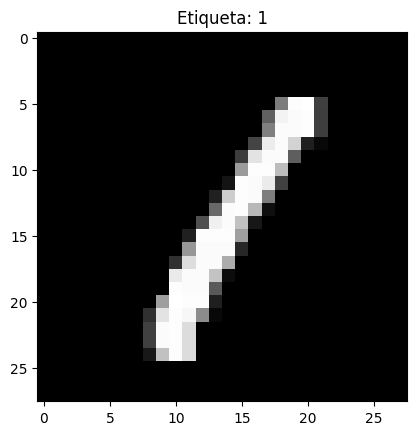

torch.Size([1, 28, 28])


In [9]:
image, label = train_dataset[3]
plt.imshow(image.permute(1, 2, 0).cpu(), cmap = 'gray')
plt.title(f"Etiqueta: {label}")
plt.show()
print(image.shape)

In [10]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

In [11]:
def learning_loop(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop):
  epoch_loss_list = []
  val_loss_list = []

  opt = optimizer(model.parameters(),
                  lr=learning_rate)

  with tqdm(range(epochs), desc="Epoch:") as pbar:
    for epoch in pbar:
      steps_loss_list = []
      for x_true, y_true in train_dataloader:
        _, x_rec = model(x_true)                           # Forward
        opt.zero_grad()

        loss = loss_fn(x_rec, x_true)
        loss.backward()                                     # Backward
        steps_loss_list.append(loss.clone().detach())
        opt.step()

      train_loss = torch.tensor(steps_loss_list).mean()
      epoch_loss_list.append(train_loss.cpu())
      pbar.set_postfix(loss=f"{train_loss:.4f}")

      if epoch % validation_freq == 0:
        val_step_loss_list = []

        with torch.no_grad():
          for x_val_true, y_val_true in val_dataloader:
            _, x_val_rec = model(x_val_true)

            loss_val = loss_fn(x_val_rec, x_val_true)
            val_step_loss_list.append(loss_val)

          val_loss = torch.tensor(val_step_loss_list).mean()
          val_loss_list.append(val_loss.cpu())

        early_stop.check_stop(val_loss)
        if early_stop.stop:
          print(f"\nEarly Stop en la época {epoch}.")
          break

  return model, epoch_loss_list, val_loss_list

In [12]:
def covariance_ellipse(points, num_of_stds=2.0, **kwargs):
    center = np.mean(points, axis=0)
    cov = np.cov(points, rowvar=False) # Calculate covariance matrix.

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])) # Angle of rotation.
    width, height = 2 * num_of_stds * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)

    return ellipse

## Experimento con espacio latente sin restricción y sigmoide para salida:

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_space = self.encoder(x)
        reconstructed_x = self.decoder(latent_space)
        reconstructed_x = reconstructed_x.view(-1, 1, 28, 28)

        return latent_space, reconstructed_x

Epoch::   5%|▌         | 100/2000 [00:41<13:17,  2.38it/s, loss=0.0337]


Early Stop en la época 100.


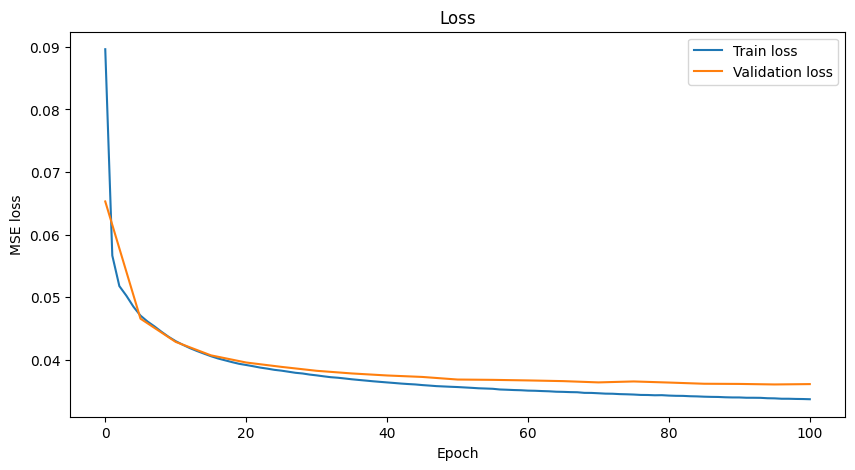

In [14]:
batch_size = 256
learning_rate = 1e-3
epochs = 2000
validation_freq = 5
patience = 10
delta = 0.001
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = Autoencoder(latent_dims=2).to(device)
early_stop = Early_Stop(patience=patience, delta=delta)

model, train_loss_list, val_loss_list = learning_loop(
    train_loader, val_loader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop
)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train loss')
plt.plot(np.arange(0, len(train_loss_list), validation_freq), val_loss_list, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.show()

In [15]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_set_size = 0

with torch.no_grad():
    for x_true, y_true in test_loader:

        _, x_rec = model(x_true)
        test_loss = loss_fn(x_rec, x_true)
        test_step_loss_list.append(test_loss.item())

final_test_mae = torch.tensor(test_step_loss_list).mean()
print(f"Error absoluto medio en el conjunto de test: {final_test_mae:.6f}")

Error absoluto medio en el conjunto de test: 0.048294


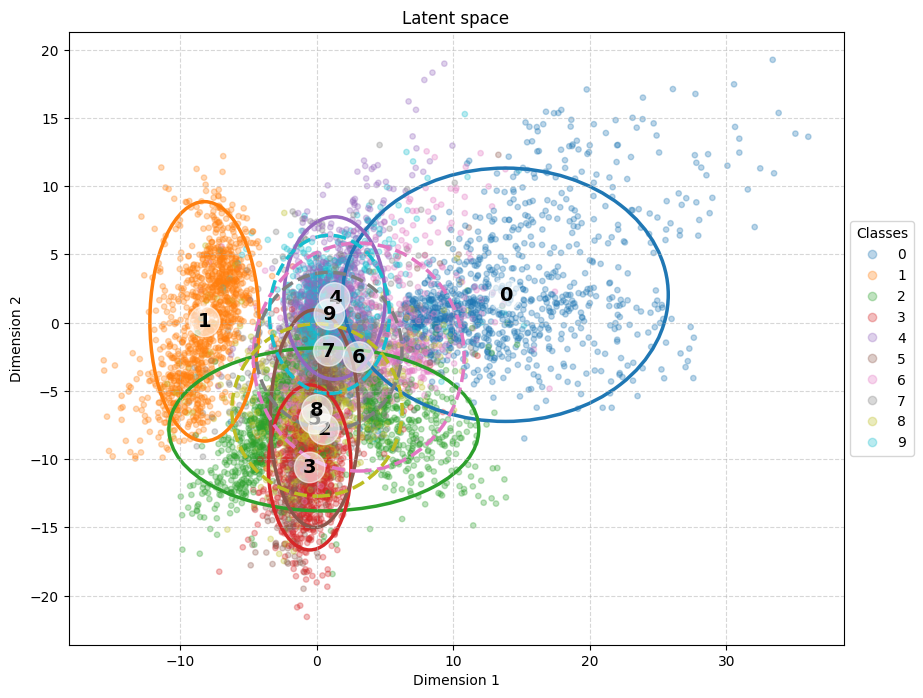

In [16]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-' if clase <= 5 else '--')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')

    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

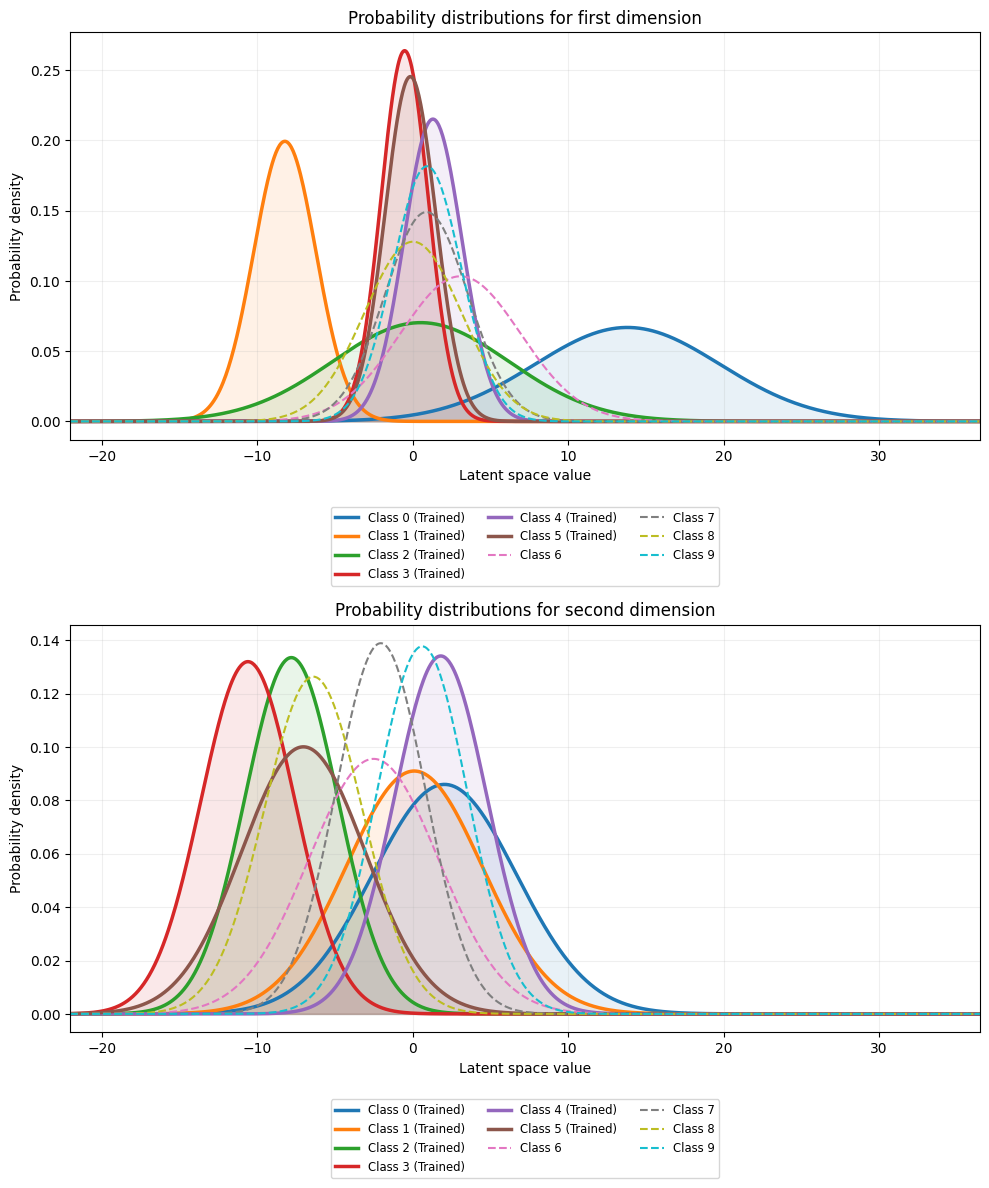

In [17]:
x_min = encodings_np.min() - 0.5  # Un poco de margen a la izquierda
x_max = encodings_np.max() + 0.5  # Un poco de margen a la derecha
x_range = np.linspace(x_min, x_max, 1000)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

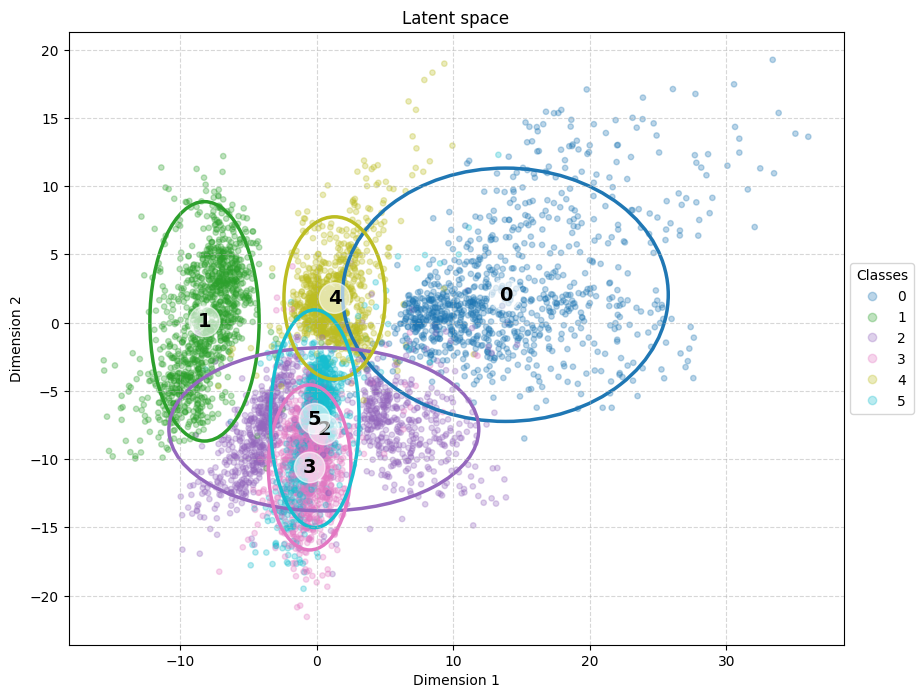

In [18]:
encodings_list = []
labels_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader:
        latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')


    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [19]:
all_y_residuals = []

with torch.no_grad():
    for x_true, _ in train_loader:
        _, x_rec = model(x_true)

        y_obs = torch.atan(torch.pi * x_true - (torch.pi / 2))
        y_mu = torch.atan(torch.pi * x_rec - (torch.pi / 2))

        # Calculate the error
        residual = y_obs - y_mu
        all_y_residuals.append(residual)

all_y_residuals = torch.cat(all_y_residuals, dim=0)

# Calculates a specific standard deviation for each of the 784 pixels.
sigma_ij = torch.std(all_y_residuals, dim=0)
sigma_ij = sigma_ij + 1e-6 # To prevent division-by-zero errors

In [21]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

all_ood_flags = []

with torch.no_grad():
    for x_true, y_true in test_loader:
        _, x_rec = model(x_true)

        # Transformed observation
        y_obs = torch.atan(torch.pi * x_true - (torch.pi / 2))

        # Transformed reconstruction, acting as the In-Distribution mean E[y|In]
        y_mu = torch.atan(torch.pi * x_rec - (torch.pi / 2))

        # In-Distribution model
        sigma = sigma_ij
        log_p_in_comp = -0.5 * math.log(2 * math.pi) - torch.log(sigma) - ((y_obs - y_mu)**2 / (2 * sigma**2))
        log_p_in = log_p_in_comp.sum(dim=1)

        # Out-of-Distribution model
        log_p_out_comp = -math.log(math.pi) - 2 * torch.log(torch.abs(torch.cos(y_obs)))
        log_p_out = log_p_out_comp.sum(dim=1)

        # Bayes theorem
        # To prevent float overflow from doing torch.exp() on massive numbers, we divide the numerator and denominator by p_out.
        prob_ood = 1.0 / (1.0 + torch.exp(log_p_in - log_p_out))

        # An image is OOD if OOD probability > 0.5
        is_ood = prob_ood > 0.5
        all_ood_flags.extend(is_ood.cpu().tolist())

print(f"OOD images detected: {sum(all_ood_flags)} / {len(all_ood_flags)}")

TypeError: unsupported operand type(s) for +: 'int' and 'list'